# Phase 4: ToxNet Training — Two-Pass Bootstrap + OPTUNA
### Pipeline:
1. Load Phase 2 & 3 artifacts (fingerprints, splits, SMOTE validity map)
2. Run OPTUNA search (200 trials, early stopping at 10 stagnant)
3. Full Two-Pass Bootstrap training with best hyperparameters
4. Save complete model artifact bundle

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import torch
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from src.train import get_device, run_full_pipeline
from src.focal_loss import PerEndpointFocalLoss

TARGET_COLS = [
    'NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD',
    'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53'
]

device = get_device()
print('Ready.')

GPU active: NVIDIA GeForce RTX 5050 Laptop GPU
Ready.


In [2]:
# ── Load Phase 2 feature matrices ────────────────────────────────────────────
print('Loading Phase 2 feature matrices...')
X_fp_train = np.load('../data/processed/splits/X_fp_train.npy')
X_fp_val   = np.load('../data/processed/splits/X_fp_val.npy')
train_idx  = np.load('../data/processed/splits/train_idx.npy')
val_idx    = np.load('../data/processed/splits/val_idx.npy')

df = pd.read_csv('../data/processed/tox21_cleaned.csv')
Y_all   = df[TARGET_COLS].values
Y_train = Y_all[train_idx]
Y_val   = Y_all[val_idx]

print(f'X_fp_train: {X_fp_train.shape}  |  Y_train: {Y_train.shape}')
print(f'X_fp_val:   {X_fp_val.shape}    |  Y_val:   {Y_val.shape}')

Loading Phase 2 feature matrices...
X_fp_train: (5460, 4096)  |  Y_train: (5460, 12)
X_fp_val:   (780, 4096)    |  Y_val:   (780, 12)


In [3]:
# ── Load Phase 3 SMOTE validity map ──────────────────────────────────────────
print('Loading Phase 3 cohesion artifacts...')
with open('../data/processed/phase3_artifacts.pkl', 'rb') as f:
    phase3 = pickle.load(f)

cohesion_df    = phase3['cohesion_df']
opt_threshold  = phase3['optimal_threshold']
smote_valid_map = dict(zip(cohesion_df['endpoint'], cohesion_df['smote_valid']))

print(f'Optimal SMOTE threshold: {opt_threshold}')
print(f'SMOTE-valid endpoints: {sum(smote_valid_map.values())}/12')
for ep, valid in smote_valid_map.items():
    status = '✅ SMOTE valid' if valid else '❌ Focal Loss only (NR-AhR)'
    print(f'  {ep}: {status}')

Loading Phase 3 cohesion artifacts...
Optimal SMOTE threshold: 1.5
SMOTE-valid endpoints: 11/12
  NR-AhR: ❌ Focal Loss only (NR-AhR)
  NR-ER-LBD: ✅ SMOTE valid
  NR-AR: ✅ SMOTE valid
  NR-AR-LBD: ✅ SMOTE valid
  NR-ER: ✅ SMOTE valid
  NR-PPAR-gamma: ✅ SMOTE valid
  SR-MMP: ✅ SMOTE valid
  SR-ATAD5: ✅ SMOTE valid
  NR-Aromatase: ✅ SMOTE valid
  SR-p53: ✅ SMOTE valid
  SR-HSE: ✅ SMOTE valid
  SR-ARE: ✅ SMOTE valid


In [4]:
# ── Run Full Pipeline ─────────────────────────────────────────────────────────
# This cell runs the full OPTUNA search + Two-Pass Bootstrap training.
# Expected time with GPU: ~45-90 minutes for 200-trial OPTUNA search.

lite_model, full_model, best_params, study, X_val_emb = run_full_pipeline(
    X_train_fp=X_fp_train,
    Y_train=Y_train,
    X_val_fp=X_fp_val,
    Y_val=Y_val,
    target_cols=TARGET_COLS,
    smote_valid_map=smote_valid_map,
    device=device,
    n_optuna_trials=200,
    n_final_epochs=100,
)

PHASE 4: Two-Pass Bootstrap + OPTUNA
Device: cuda
OPTUNA trials: 200 (early stop after 10 stagnant)

[Step 1] Running OPTUNA hyperparameter search...
  SMOTE augmentation: 5460 → 50087 samples (+44627 synthetic)
  Trial   0: AUPRC=0.4100 ★ NEW BEST
  SMOTE augmentation: 5460 → 50082 samples (+44622 synthetic)
  SMOTE augmentation: 5460 → 49975 samples (+44515 synthetic)
  SMOTE augmentation: 5460 → 50052 samples (+44592 synthetic)
  SMOTE augmentation: 5460 → 50139 samples (+44679 synthetic)
  SMOTE augmentation: 5460 → 50067 samples (+44607 synthetic)
  SMOTE augmentation: 5460 → 50051 samples (+44591 synthetic)
  Trial   6: AUPRC=0.4291 ★ NEW BEST
  SMOTE augmentation: 5460 → 49914 samples (+44454 synthetic)
  SMOTE augmentation: 5460 → 50081 samples (+44621 synthetic)
  SMOTE augmentation: 5460 → 49975 samples (+44515 synthetic)
  SMOTE augmentation: 5460 → 49944 samples (+44484 synthetic)
  Trial  10: AUPRC=0.4048 (stagnant: 4/10)
  SMOTE augmentation: 5460 → 50018 samples (+44558 

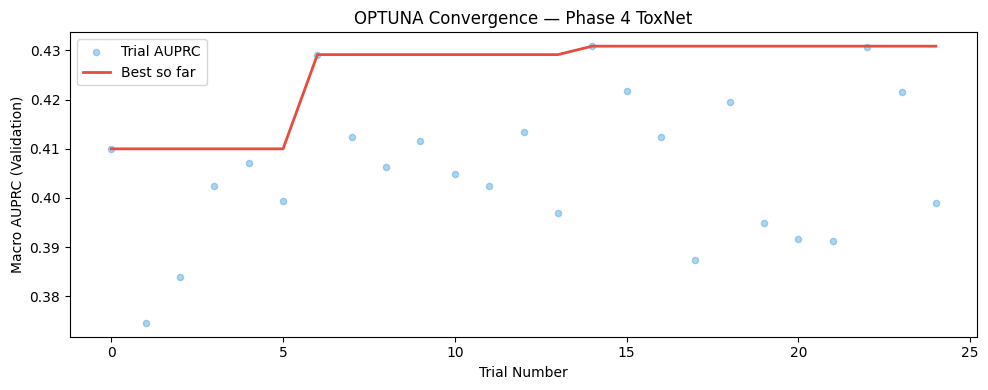

Converged at trial 25 / 200


In [7]:
# ── Plot OPTUNA Convergence Curve ─────────────────────────────────────────────
import matplotlib.pyplot as plt

trial_nums  = [t.number for t in study.trials if t.value is not None]
trial_vals  = [t.value for t in study.trials if t.value is not None]
best_so_far = [max(trial_vals[:i+1]) for i in range(len(trial_vals))]

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(trial_nums, trial_vals, alpha=0.4, color='#3498db', s=20, label='Trial AUPRC')
ax.plot(trial_nums, best_so_far, color='#e74c3c', linewidth=2, label='Best so far')
ax.set_xlabel('Trial Number')
ax.set_ylabel('Macro AUPRC (Validation)')
ax.set_title('OPTUNA Convergence — Phase 4 ToxNet')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/optuna_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Converged at trial {len(study.trials)} / 200')

In [8]:
# ── Save Complete Model Artifact Bundle (Roadmap Fix #4) ──────────────────────
# NEVER save only the .pt weights. Bundle everything needed for inference.
os.makedirs('../models', exist_ok=True)

# Load the scaler from Phase 2
with open('../data/processed/splits/descriptor_scaler.pkl', 'rb') as f:
    descriptor_scaler = pickle.load(f)

artifact = {
    'lite_model_state':  lite_model.state_dict(),
    'full_model_state':  full_model.state_dict(),
    'lite_model_config': {'input_dim': X_fp_train.shape[1], 'shared_dims': [512, 256]},
    'full_model_config': {'input_dim': 256, 'shared_dims': best_params.get('shared_dims', [256, 128])},
    'best_params':       best_params,
    'scaler':            descriptor_scaler,
    'target_cols':       TARGET_COLS,
    'smote_valid_map':   smote_valid_map,
    'optuna_best_value': study.best_value,
    'n_trials_run':      len(study.trials),
    'fp_radius':         2,
    'fp_n_bits':         4096,
    'thresholds':        {col: 0.5 for col in TARGET_COLS},  # Updated in Phase 5
    'temperatures':      {col: 1.0 for col in TARGET_COLS},  # Updated in Phase 5
}

with open('../models/model_artifact.pkl', 'wb') as f:
    pickle.dump(artifact, f)

# Also save raw weights separately for torch.load() convenience
torch.save(lite_model.state_dict(), '../models/toxnet_lite.pt')
torch.save(full_model.state_dict(), '../models/toxnet_final.pt')

print('Model artifact bundle saved to models/')
print(f'  lite weights:     models/toxnet_lite.pt')
print(f'  full weights:     models/toxnet_final.pt')
print(f'  complete bundle:  models/model_artifact.pkl')
print(f'\nBest Macro AUPRC:  {study.best_value:.4f}')
print(f'Best params:       {best_params}')
print('\nPhase 4 Complete.')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

...


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found

Model artifact bundle saved to models/
  lite weights:     models/toxnet_lite.pt
  full weights:     models/toxnet_final.pt
  complete bundle:  models/model_artifact.pkl

Best Macro AUPRC:  0.4308
Best params:       {'dropout': 0.41336916778565586, 'batch_size': 128, 'weight_decay': 0.0009417708243085272, 'shared_dims': [256, 128], 'learning_rate': 0.0038552325572212367, 'focal_gamma': 3.6117190001639132}

Phase 4 Complete.


In [6]:
%pip install matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 8.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 7.8 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 8.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
